In [43]:
# Importing necessary libraries

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from scipy.special import j0, j1 # Bessel functions of the first kind for part 2
from scipy.optimize import brentq # Used in part 3

In [44]:
def expand_regions(regions):
    D1, D2, Sa1, Sa2, Ss12, nSf1, nSf2, dx, = [], [], [], [], [], [], [], []

    for reg in regions:
        Nc = reg['Nc']
        D1.extend([reg['D1']] * Nc)
        D2.extend([reg['D2']] * Nc)
        Sa1.extend([reg['Sa1']] * Nc)
        Sa2.extend([reg['Sa2']] * Nc)
        Ss12.extend([reg['Ss12']] * Nc)
        nSf1.extend([reg['nSf1']] * Nc)
        nSf2.extend([reg['nSf2']] * Nc)
        dx.extend([reg['dx']] * Nc)
    
    D1 = np.array(D1, dtype=float)
    D2 = np.array(D2, dtype=float)
    Sa1 = np.array(Sa1, dtype=float)
    Sa2 = np.array(Sa2, dtype=float)
    Ss12 = np.array(Ss12, dtype=float)
    nSf1 = np.array(nSf1, dtype=float)
    nSf2 = np.array(nSf2, dtype=float)
    dx = np.array(dx, dtype=float)

    x_edges = np.concatenate(([0.0], np.cumsum(dx)))
    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])

    return x_centers, D1, D2, Sa1, Sa2, Ss12, nSf1, nSf2, dx

In [45]:
def build_loss_matrix(D, Sig_r, dx, bc_type="reflecting"):
    """
    Builds tridiagonal matrix for a 1D diffusion system.
    Applies either 'reflecting' or 'vacuum' (zero incident partial current)
    boundary conditions at both the top and the bottom of the reactor.
    """
    N = len(D)

    lower = np.zeros(N)
    diag = np.zeros(N)
    upper = np.zeros(N)

    # Interior interface conductances
    F = np.zeros(N - 1) # F array ensures leakage is conserved across interfaces
    for i in range(N - 1):
        F[i] = 1.0 / (0.5 * dx[i] / D[i] + 0.5 * dx[i+1] / D[i+1])

    for i in range(N):
        diag[i] += Sig_r[i] * dx[i]

        if i > 0:
            lower[i] = -F[i-1]
            diag[i] += F[i-1]

        if i < N - 1:
            upper[i] = -F[i]
            diag[i] += F[i]

    # Apply external boundary conditions based on selected type
    if bc_type == "vacuum":
        # Left Boundary Condition (zero incident partial current)
        beta_left = 2.0 * D[0] / dx[0]
        alpha_left = beta_left / (2.0 * beta_left + 1.0)
        diag[0] += alpha_left

        # Right Boundary Condition (zero incident partial current)
        beta_right = 2.0 * D[-1] / dx[-1]
        alpha_right = beta_right / (2.0 * beta_right + 1.0)
        diag[-1] += alpha_right
        
    elif bc_type == "reflecting":
        # Net current J = 0 at outer edges. No additional boundary leakage 
        pass

    A = diags(
        diagonals=[lower[1:], diag, upper[:-1]],
        offsets=[-1, 0, 1],
        format="csr"
    )

    return A


In [46]:
def solve_two_group_k_eigenvalue(
    regions,
    k_tol=1e-8,
    source_tol=1e-8,
    max_iters=500,
    bc_type="reflecting"
):
    x, D1, D2, Sa1, Sa2, Ss12, nSf1, nSf2, dx = expand_regions(regions)
    N = len(x)

    # Removal cross sections
    Sr1 = Sa1 + Ss12   # Fast removal: Absorption + Scattering
    Sr2 = Sa2          # Thermal removal: Absorption

    # Building the loss matrices for both groups using the specified BC
    A1 = build_loss_matrix(D1, Sr1, dx, bc_type=bc_type)
    A2 = build_loss_matrix(D2, Sr2, dx, bc_type=bc_type)

    k = 1.0
    phi1 = np.ones(N)
    phi2 = np.ones(N)

    # Initial fission source
    fission_source = (nSf1 * phi1 + nSf2 * phi2) * dx
    fission_source /= np.sum(fission_source)

    for iteration in range(1, max_iters + 1):
        # Step 1: Solving fast group
        rhs1 = fission_source / k
        phi1_new = spsolve(A1, rhs1)

        # Step 2: Solving thermal group (source is from scattering from fast group)
        rhs2 = Ss12 * phi1_new * dx
        phi2_new = spsolve(A2, rhs2)

        # Step 3: Calculating new fission source
        fission_source_raw = (nSf1 * phi1_new + nSf2 * phi2_new) * dx
        k_new = k * np.sum(fission_source_raw) / np.sum(fission_source)

        # Step 4: Normalizing fluxes
        normalization_factor = np.sum(fission_source_raw)
        phi1_new /= normalization_factor
        phi2_new /= normalization_factor
        fission_source_new = fission_source_raw / normalization_factor

        # Step 5: Checking for convergence
        k_error = abs(k_new - k) / abs(k)
        source_error = np.linalg.norm(fission_source_new - fission_source, ord=np.inf) / np.linalg.norm(fission_source, ord=np.inf)

        if k_error < k_tol and source_error < source_tol:
            return x, phi1_new, phi2_new, k_new, nSf1, nSf2
        
        k = k_new
        phi1 = phi1_new
        phi2 = phi2_new
        fission_source = fission_source_new
    
    print("ERROR: Power iteration failed to converge within the maximum number of iterations.")
    return x, phi1_new, phi2_new, k_new, nSf1, nSf2

In [47]:
def make_region(fuel_dict, length_cm, num_cells, label):
    reg = fuel_dict.copy()
    reg['Nc'] = num_cells
    reg['dx'] = length_cm / num_cells
    reg['label'] = label
    return reg

In [48]:
def plot_reactor_results(x, phi1, phi2, normalized_power, given_core_layout):
    """
    Function built to plot the results of the two-group diffusion solver.
    This is needed so that I can test various different core layouts and compare them in terms of Keff and PPF
    """
    # Plotting results
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

    # Plot 1: Flux Profiles
    ax1.plot(x, phi1, label=r'Fast Flux ($\phi_1$)', color='blue', linewidth=2)
    ax1.plot(x, phi2, label=r'Thermal Flux ($\phi_2$)', color='red', linewidth=2)
    ax1.set_ylabel("Relative Flux")
    ax1.set_title("Axial Fast and Thermal Flux Shapes")
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()

    # Color pallete for different fuel types
    default_colors = {
        "Fresh": "#d4f1f9", 
        "Once-Burned": "#f9ebd4", 
        "Twice-Burned": "#f9d4d4",
        "Reflector": "#e2e2e2"
    }

    # apply background color spans and text labels
    current_x = 0
    for reg in given_core_layout:
        reg_length = reg["dx"] * reg["Nc"]
        label = reg.get("label", "Unknown")
        bg_color = default_colors.get(label, "#f0f0f0") # Fallback to light grey
        
        # background shading
        ax1.axvspan(current_x, current_x + reg_length, color=bg_color, alpha=0.4)
        ax2.axvspan(current_x, current_x + reg_length, color=bg_color, alpha=0.4)
        
        # label text at the top of the bottom plot
        ax2.text(current_x + reg_length/2, 1.02, label, 
                 ha='center', va='bottom', fontsize=9, rotation=0)
        
        current_x += reg_length

    # Plot 2: Normalized Power Distribution
    ax2.plot(x, normalized_power, label="Normalized Power", color='purple', linewidth=2)
    ax2.axhline(1.0, color='black', linestyle='--', label="Average Power", alpha=0.5)
    
    ax2.set_xlabel("Axial Position (cm)")
    ax2.set_ylabel(r"Normalized Power ($P/P_{ave}$)")
    ax2.set_title("Axial Power Distribution")
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()
    

In [49]:
def output_results(x, phi1, phi2, k, nSf1, nSf2, output_core_layout):
    # Calculate Power & Peaking
    power_distribution = nSf1 * phi1 + nSf2 * phi2
    p_ave = np.mean(power_distribution)
    p_max = np.max(power_distribution)
    peaking_factor = p_max / p_ave
    normalized_power = power_distribution / p_ave

    print(f"--- Core Calculation Results ---")
    print(f"k-effective: {k:.5f}")
    print(f"Power Peaking Factor: {peaking_factor:.5f}")
    print(f"Target met? k > 1.05: {k > 1.05}, PPF: < 1.15: {peaking_factor < 1.15}")

    plot_reactor_results(x, phi1, phi2, normalized_power, output_core_layout)


### **Hand Calculation Verification**
The code is verified by solving a problem with homogenous material properties and comparing the result with a hand-calculated multiplication factor ($k_\infty$ and $k$) using the six-factor formula

$$\Sigma_{a2}\phi_2=\Sigma_{s,1\rightarrow2}\phi_1$$
$$\frac{\phi_2}{\phi_1}=\frac{\Sigma_{s,1\rightarrow2}(z)\phi_1}{\Sigma_{a2}}=\frac{0.0068}{0.0105}=0.6476$$
$$\rho=\nu\Sigma_{f1}\phi_1+\nu\Sigma_{f2}\phi_2=0.0035\phi_1+0.0145(0.6476)\phi_1=0.00974\phi_1$$
$$L=\phi_1\left(\Sigma_{a1}+\Sigma_{s,1\rightarrow2}\right)=\phi_1\left(0.0012+0.0068\right)=0.00800\phi_1$$
$$k_\infty=\frac{\rho}{L}=\frac{0.00974\phi_1}{0.00800\phi_1}=1.217$$

In [50]:
# Fuel properties given in Table 1
fresh = {"D1": 1.55, "D2": 0.82, "Sa1": 0.0012, "Sa2": 0.0105, "Ss12": 0.0068, "nSf1": 0.00035, "nSf2": 0.0145}
once  = {"D1": 1.50, "D2": 0.80, "Sa1": 0.0016, "Sa2": 0.0125, "Ss12": 0.0065, "nSf1": 0.00045, "nSf2": 0.0132}
twice = {"D1": 1.45, "D2": 0.78, "Sa1": 0.0021, "Sa2": 0.0155, "Ss12": 0.0062, "nSf1": 0.00055, "nSf2": 0.0115}

hand_calc_k = 1.217

verification_core = [
    make_region(fresh, 600, 300, "Fresh")
]

x, phi1, phi2, k, nSf1, nSf2 = solve_two_group_k_eigenvalue(
    verification_core,
    bc_type="reflecting"
)

print("--- Code Verification Results ---")
print(f"Numerical k = {k:.5f}")
print(f"Hand-calculated k = {hand_calc_k:.3f}")
print(f"The numerical and hand-calculated k values are the same to 2 decimal places: {round(k, 2) == round(hand_calc_k, 2)}")

--- Code Verification Results ---
Numerical k = 1.21756
Hand-calculated k = 1.217
The numerical and hand-calculated k values are the same to 2 decimal places: True


--- Core Calculation Results ---
k-effective: 1.10878
Power Peaking Factor: 2.59705
Target met? k > 1.05: True, PPF: < 1.15: False


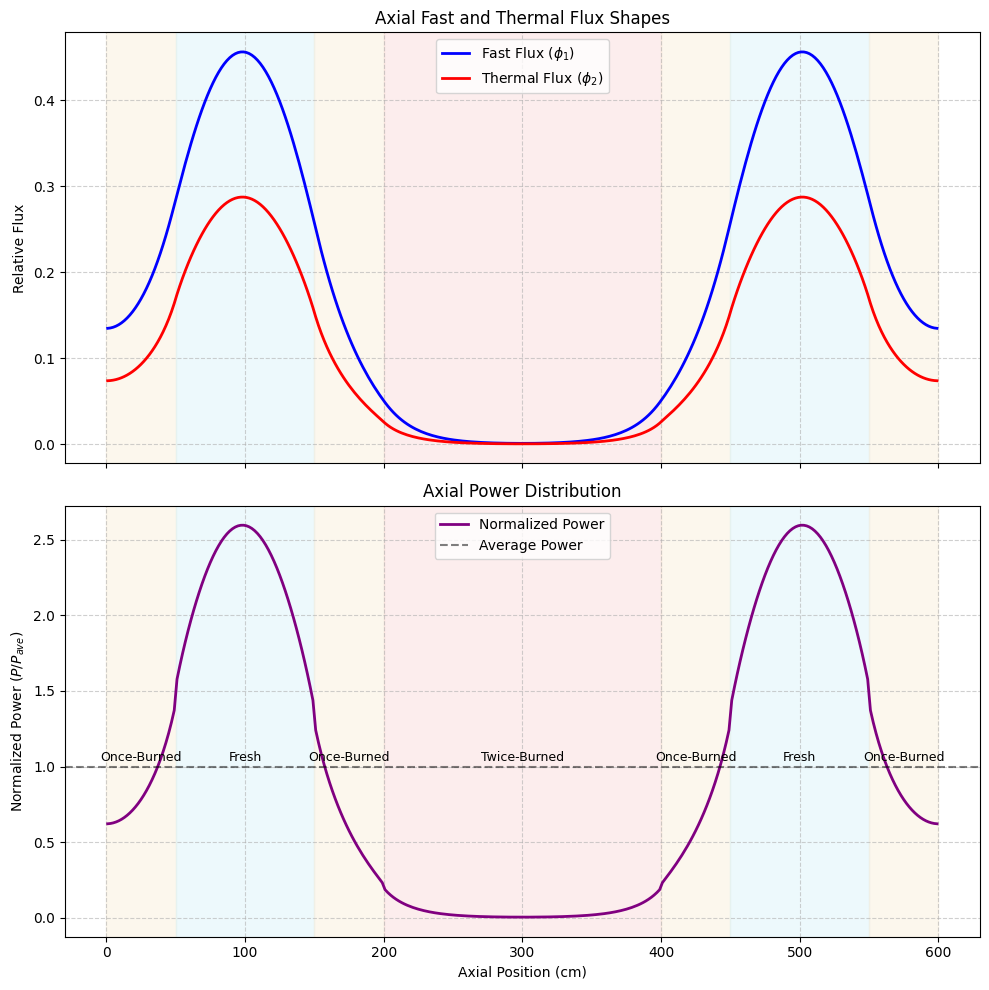

In [51]:
# Chosen core layout based on testing
core_layout_1 = [

    make_region(once,  50, 25, "Once-Burned"),

    make_region(fresh,  100, 50, "Fresh"),

    make_region(once,  50, 25, "Once-Burned"),

    make_region(twice,  200, 100, "Twice-Burned"),

    make_region(once,  50, 25, "Once-Burned"),

    make_region(fresh,  100, 50, "Fresh"),
    
    make_region(once,  50, 25, "Once-Burned"),
]

x, phi1, phi2, k, nSf1, nSf2 = solve_two_group_k_eigenvalue(core_layout_1, bc_type="reflecting")
output_results(x, phi1, phi2, k, nSf1, nSf2, core_layout_1)


In [52]:
def solve_2d_cylindrical_eigenvalue(
    regions,
    Br2,
    k_tol=1e-8,
    source_tol=1e-8,
    max_iters=500,
    bc_type="reflecting"
):
    x, D1, D2, Sa1, Sa2, Ss12, nSf1, nSf2, dx = expand_regions(regions)
    N = len(x)

    # Removal cross sections, modified to include new radial leakage term (D * Br^2)
    Sr1 = Sa1 + Ss12 + (D1 * Br2)   # Fast removal: Absorption + Scattering + Radial Leakage
    Sr2 = Sa2 + (D2 * Br2)          # Thermal removal: Absorption + Radial Leakage

    # Building the loss matrices for both groups using the specified BC
    A1 = build_loss_matrix(D1, Sr1, dx, bc_type=bc_type)
    A2 = build_loss_matrix(D2, Sr2, dx, bc_type=bc_type)

    k = 1.0
    phi1 = np.ones(N)
    phi2 = np.ones(N)

    # Initial fission source
    fission_source = (nSf1 * phi1 + nSf2 * phi2) * dx
    fission_source /= np.sum(fission_source)


    for it in range(1, max_iters + 1):
        # Step 1: Solving fast group
        rhs1 = fission_source / k
        phi1_new = spsolve(A1, rhs1)

        # Step 2: Solving thermal group (source is from scattering from fast group)
        rhs2 = Ss12 * phi1_new * dx
        phi2_new = spsolve(A2, rhs2)

        # Step 3: Calculating new fission source
        fission_source_raw = (nSf1 * phi1_new + nSf2 * phi2_new) * dx
        k_new = k * np.sum(fission_source_raw) / np.sum(fission_source)

        # Step 4: Normalizing fluxes
        normalization_factor = np.sum(fission_source_raw)
        phi1_new /= normalization_factor
        phi2_new /= normalization_factor
        fission_source_new = fission_source_raw / normalization_factor

        # Step 5: Checking for convergence
        k_error = abs(k_new - k) / abs(k)
        source_error = np.linalg.norm(fission_source_new - fission_source, ord=np.inf) / np.linalg.norm(fission_source, ord=np.inf)


        if k_error < k_tol and source_error < source_tol:
            return x, phi1_new, phi2_new, k_new, nSf1, nSf2
        
        k = k_new
        phi1 = phi1_new
        phi2 = phi2_new
        fission_source = fission_source_new
    
    print("ERROR: Power iteration failed to converge within the maximum number of iterations.")
    return x, phi1_new, phi2_new, k_new, nSf1, nSf2

Radial Buckling (Br^2): 3.614505e-05 cm^-2
--- 2D Cylindrical Reactor Results ---
2D k-effective: 1.09853
2D Power Peaking Factor: 6.01852


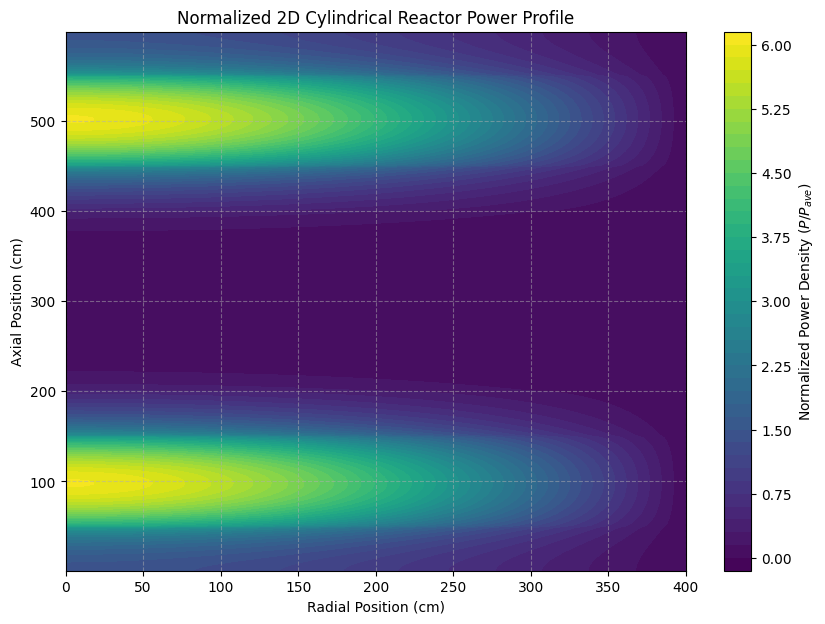

In [53]:
# Core dimensions:

R_core = 400.0 #cm, or 4 meters tall
H_core = 600.0 #cm, or 6 meters tall

# Calculate constant radial buckling:
bessel_zero = 2.40483
Br = bessel_zero / R_core
Br2 = Br**2

print(f"Radial Buckling (Br^2): {Br2:.6e} cm^-2")

# Define radial grid for plotting and analysis
num_r_points = 50
r_grid = np.linspace(0, R_core, num_r_points)

# Analytical radial flux shape normalized to an average value of 1.0
# The average of J0(Br*r) over the cross-section is (2 * J1(Br*R)) / (Br*R)
radial_avg_j0 = (2.0 * j1(bessel_zero)) / bessel_zero
radial_power_shape = j0(Br * r_grid) / radial_avg_j0

# Executing code using fuel layout from Section 1
x_centers, phi1_2d, phi2_2d, k_2d, nSf1_arr, nSf2_arr = solve_2d_cylindrical_eigenvalue(core_layout_1, Br2, bc_type="reflecting")

# Calculate normalized axial power distribution
axial_power = nSf1_arr * phi1_2d + nSf2_arr * phi2_2d
axial_power_norm = axial_power / np.mean(axial_power)

# Use Meshgrid to superimpose profiles across 2D space
R_mesh, Z_mesh = np.meshgrid(r_grid, x_centers)
P_mesh = np.zeros_like(R_mesh)

for i in range(len(x_centers)):
    P_mesh[i, :] = axial_power_norm[i] * radial_power_shape

# Calculate final power peaking factor for the assembly
ppf_2d = np.max(P_mesh) / 1.0  # Normalized average is 1.0
print(f"--- 2D Cylindrical Reactor Results ---")
print(f"2D k-effective: {k_2d:.5f}")
print(f"2D Power Peaking Factor: {ppf_2d:.5f}")

# Render the Plot
plt.figure(figsize=(10, 7))
contour = plt.contourf(R_mesh, Z_mesh, P_mesh, 50, cmap='viridis')
plt.colorbar(contour, label=r"Normalized Power Density ($P / P_{ave}$)")
plt.title("Normalized 2D Cylindrical Reactor Power Profile")
plt.xlabel("Radial Position (cm)")
plt.ylabel("Axial Position (cm)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Core volume = 301.593 m^3
Average power density = 6.631e+05 W/m^3

Maximum centerline temperature = 936.96 K
Minimum centerline temperature = 900.00 K

Hottest location:
r = 0.00 cm
z = 99.00 cm


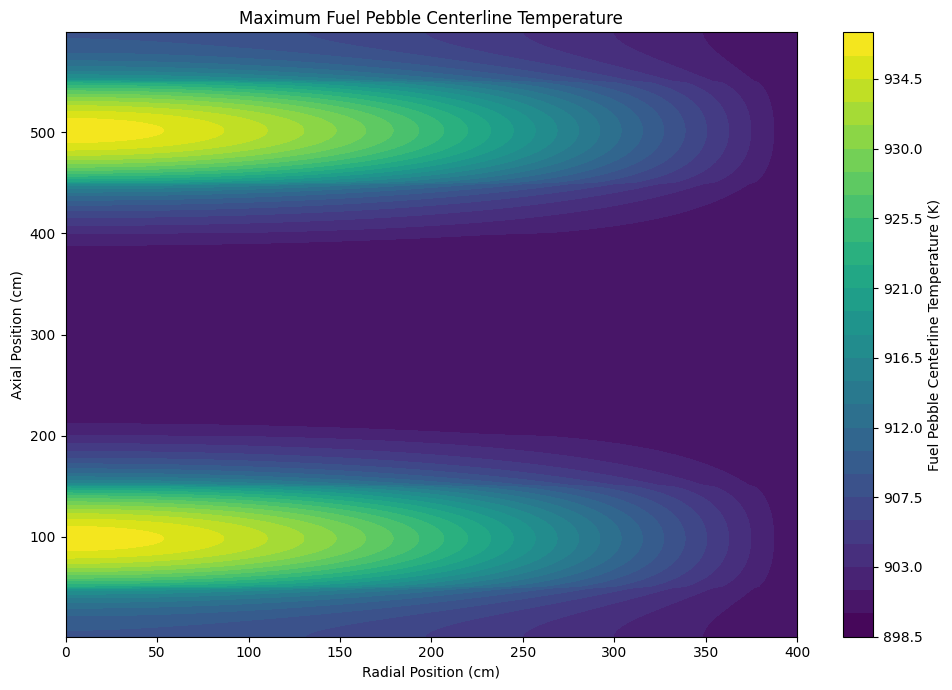

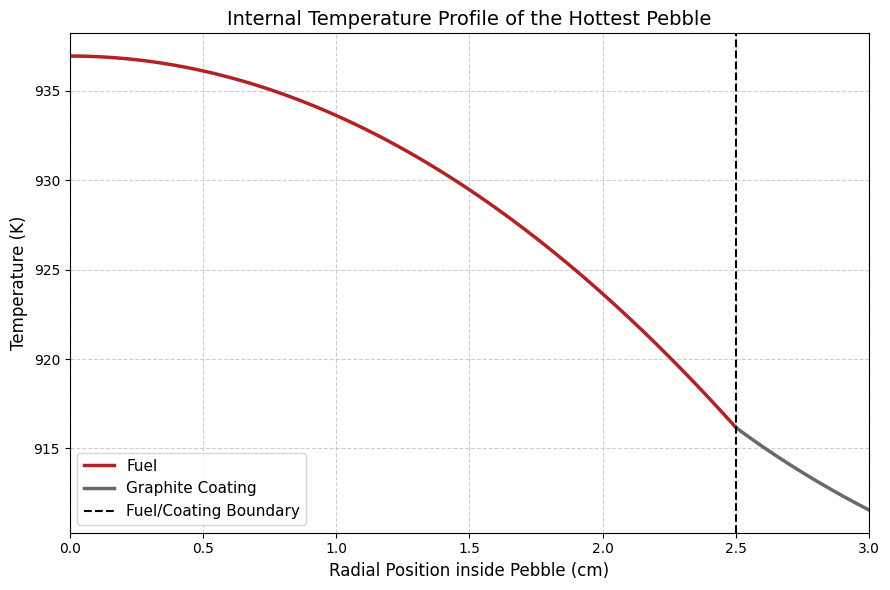

In [54]:
# Thermal parameters from Table 2
T_cool = 900.0 # K
rf = 0.025 # m
tc = 0.005 # m
ro = rf + tc # m
kf = 20.0 # W/m-K
kc = 30.0 # W/m-K
h = 2000.0 # W/m^2-K

# Core geometry
R_core = 4.0 # m
H_core = 6.0 # m
P_core = 200e6 # W

# Average volumetric power density
V_core = np.pi * R_core**2 * H_core
q_avg = P_core / V_core

print(f"Core volume = {V_core:.3f} m^3")
print(f"Average power density = {q_avg:.3e} W/m^3")

# Local power density
q_local = q_avg * P_mesh

# Temperature rise components
Q_pebble = q_local * (4/3) * np.pi * rf**3 # heat leaving one pebble
A_pebble = 4 * np.pi * ro**2 # pebble surface area
dT_conv = Q_pebble / (h * A_pebble) # convection rise


dT_coating = (q_local * rf**3 / (3 * kc) * (1/rf - 1/ro)) # graphite coating rise
dT_fuel = q_local * rf**2 / (6 * kf) # fuel-center rise

# total centerline temperature
T_center = T_cool + dT_conv + dT_coating + dT_fuel

# Results
print(f"\nMaximum centerline temperature = {np.max(T_center):.2f} K")
print(f"Minimum centerline temperature = {np.min(T_center):.2f} K")

imax = np.unravel_index(np.argmax(T_center), T_center.shape) # location of hottest pebble

print("\nHottest location:")
print(f"r = {R_mesh[imax]:.2f} cm")
print(f"z = {Z_mesh[imax]:.2f} cm")

# Plotting
plt.figure(figsize=(10,7))

cont = plt.contourf(R_mesh, Z_mesh, T_center, levels=30)
plt.colorbar(cont, label="Fuel Pebble Centerline Temperature (K)")

plt.xlabel("Radial Position (cm)")
plt.ylabel("Axial Position (cm)")
plt.title("Maximum Fuel Pebble Centerline Temperature")

plt.tight_layout()
plt.show()

q_max = q_local[imax] 
r_fuel = np.linspace(0, rf, 100)
r_coat = np.linspace(rf, ro, 50)

# Surface temperature (Coolant Temp + Convection Rise)
T_surf = T_cool + (q_max * rf**3) / (3 * h * ro**2)

# Coating temperature profile (Source-free spherical conduction)
T_coat_profile = T_surf + (q_max * rf**3) / (3 * kc) * (1/r_coat - 1/ro)

# Temperature exactly at the fuel/coating interface (r = rf)
T_interface = T_surf + (q_max * rf**3) / (3 * kc) * (1/rf - 1/ro)

# Fuel meat temperature profile (Uniform internal heat generation)
T_fuel_profile = T_interface + q_max / (6 * kf) * (rf**2 - r_fuel**2)

plt.figure(figsize=(9, 6))


plt.plot(r_fuel * 100, T_fuel_profile, color='firebrick', linewidth=2.5, label='Fuel')
plt.plot(r_coat * 100, T_coat_profile, color='dimgray', linewidth=2.5, label='Graphite Coating')
plt.axvline(x=rf * 100, color='black', linestyle='--', linewidth=1.5, label='Fuel/Coating Boundary')

# Formatting
plt.xlabel('Radial Position inside Pebble (cm)', fontsize=12)
plt.ylabel('Temperature (K)', fontsize=12)
plt.title('Internal Temperature Profile of the Hottest Pebble', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.xlim(0, ro * 100)

plt.tight_layout()
plt.show()

In [55]:
def albedo_buckling(alpha, R_core, D_eff):
    if np.isclose(alpha, 1.0):
        return 0.0, 0.0
    def f(B):
        return (
            (1.0 - alpha) * j0(B * R_core) - 2.0 * (1.0 + alpha) * D_eff * B * j1(B * R_core))
    B_vac = 2.40483 / R_core
    left = 0.2 * B_vac
    right = 2.0 * B_vac

    while f(left) * f(right) > 0:
        left *= 0.5
        right *= 1.5
        if right > 0.1:
            raise RuntimeError("Could not bracket albedo buckling root.")

    Br = brentq(f, left, right)

    return Br, Br**2

alpha = 0.25
Br = 5.937403e-03 cm^-1
Br² = 3.525275e-05 cm^-2

--- 2D Cylindrical Reactor Results ---
2D k-effective = 1.09878
2D Power Peaking Factor = 5.87247


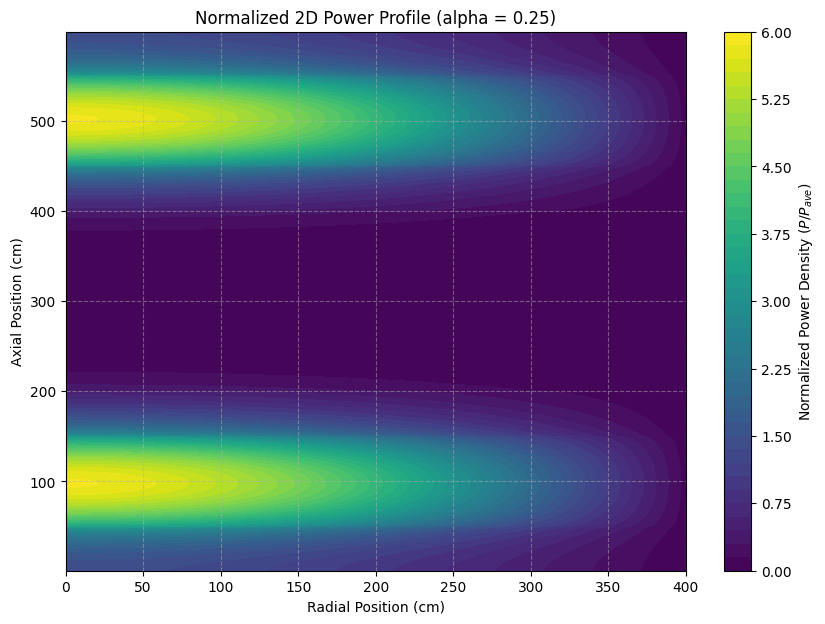

--- Albedo Parametric Study ---
alpha = 0.00 | Br² = 3.560684e-05 | k = 1.09868 
alpha = 0.25 | Br² = 3.525275e-05 | k = 1.09878 
alpha = 0.50 | Br² = 3.455591e-05 | k = 1.09898 
alpha = 0.75 | Br² = 3.255880e-05 | k = 1.09954 
alpha = 1.00 | Br² = 0.000000e+00 | k = 1.10878 


In [56]:
R_core = 400.0   # cm
H_core = 600.0   # cm

#specified "default" albedo
alpha = 0.25      # 0 = vacuum, 1 = reflecting

# Solve for buckling from:
#
# (1-alpha)J0(BR)
# - 2(1+alpha)DBJ1(BR) = 0

# Effective diffusion coefficient
D_eff = np.mean([1.55, 1.50, 1.45])

Br, Br2 = albedo_buckling(alpha, R_core, D_eff)

print(f"alpha = {alpha:.2f}")
print(f"Br = {Br:.6e} cm^-1")
print(f"Br² = {Br2:.6e} cm^-2")

# Radial grid
num_r_points = 50
r_grid = np.linspace(0, R_core, num_r_points)

# Radial power shape
if Br > 0:
    x_boundary = Br * R_core
    radial_avg_j0 = (2.0 * j1(x_boundary) / x_boundary)
    radial_power_shape = (j0(Br * r_grid) / radial_avg_j0)
else:
    radial_power_shape = np.ones_like(r_grid)


# Solve 2D reactor
x_centers, phi1_2d, phi2_2d, k_2d, nSf1_arr, nSf2_arr = solve_2d_cylindrical_eigenvalue(core_layout_1, Br2, bc_type="reflecting")

# Axial power
axial_power = (nSf1_arr * phi1_2d+ nSf2_arr * phi2_2d)

axial_power_norm = (axial_power/ np.mean(axial_power))

# Build 2D power distribution
R_mesh, Z_mesh = np.meshgrid(r_grid,x_centers)
P_mesh = np.zeros_like(R_mesh)

for i in range(len(x_centers)):
    P_mesh[i, :] = (axial_power_norm[i]* radial_power_shape)

# Results
ppf_2d = np.max(P_mesh)

print("\n--- 2D Cylindrical Reactor Results ---")
print(f"2D k-effective = {k_2d:.5f}")
print(f"2D Power Peaking Factor = {ppf_2d:.5f}")


# Plot power profile

plt.figure(figsize=(10,7))
contour = plt.contourf(R_mesh, Z_mesh, P_mesh, 50, cmap="viridis")
plt.colorbar(contour, label=r"Normalized Power Density ($P/P_{ave}$)")

plt.xlabel("Radial Position (cm)")
plt.ylabel("Axial Position (cm)")
plt.title(f"Normalized 2D Power Profile (alpha = {alpha:.2f})")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

# Verify alpha -> 0 and alpha -> 1 limits
print("--- Albedo Parametric Study ---")

alphas = [0.0, 0.25, 0.50, 0.75, 1.00]

for alpha_test in alphas:

    D_eff = np.mean([1.55, 1.50, 1.45])

    Br_test, Br2_test = albedo_buckling(alpha_test, R_core, D_eff)
    _, _, _, k_test, _, _ = solve_2d_cylindrical_eigenvalue(core_layout_1, Br2_test, bc_type="reflecting")
    ppf_2d = np.max(P_mesh) / np.mean(P_mesh)
    print(f"alpha = {alpha_test:.2f} | "f"Br² = {Br2_test:.6e} | "f"k = {k_test:.5f} ")